In [29]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Math

## 1. Parameter & Anfangsbedingungen

In [30]:
# Symbol
t = sp.symbols('t', real=True)

# Gesuchte Funktion
x = sp.Function('x')

# Koeffizienten der DGL: x'' + a*x' + b*x = f(t)
a = 3
b = 2
f = 2 * sp.sin(t)

# Anfangswerte
x0 = 0      # x(0)
dx0 = 1     # x'(0)

# Zeitintervall für Plot
t_min = 0
t_max = 10

In [31]:
ode = sp.Eq(x(t).diff(t, 2) + a*x(t).diff(t) + b*x(t), f)
display(Math(r"\text{Differentialgleichung:}"))
display(ode)

ode_hom = sp.Eq(x(t).diff(t, 2) + a*x(t).diff(t) + b*x(t), 0)
sol_hom = sp.dsolve(ode_hom)
display(Math(r"\text{Allgemeine Lösung der homogenen DGL:}"))
display(sol_hom)

sol_inhom = sp.dsolve(ode)
display(Math(r"\text{Allgemeine Lösung der inhomogenen DGL:}"))
display(sol_inhom)

ics = {
    x(0): x0,
    x(t).diff(t).subs(t, 0): dx0
}

sol_ivp = sp.dsolve(ode, ics=ics)
display(Math(r"\text{Lösung des Anfangswertproblems:}"))
display(sol_ivp)

x_ivp = sp.simplify(sol_ivp.rhs)
display(Math(r"\text{Spezielle Lösung:}"))
display(x_ivp)

x_func = sp.lambdify(t, x_ivp, modules='numpy')

t_vals = np.linspace(t_min, t_max, 400)
x_vals = x_func(t_vals)


<IPython.core.display.Math object>

Eq(2*x(t) + 3*Derivative(x(t), t) + Derivative(x(t), (t, 2)), 2*sin(t))

<IPython.core.display.Math object>

Eq(x(t), (C1 + C2*exp(-t))*exp(-t))

<IPython.core.display.Math object>

Eq(x(t), C1*exp(-2*t) + C2*exp(-t) + sin(t)/5 - 3*cos(t)/5)

<IPython.core.display.Math object>

Eq(x(t), sin(t)/5 - 3*cos(t)/5 + 2*exp(-t) - 7*exp(-2*t)/5)

<IPython.core.display.Math object>

sin(t)/5 - 3*cos(t)/5 + 2*exp(-t) - 7*exp(-2*t)/5

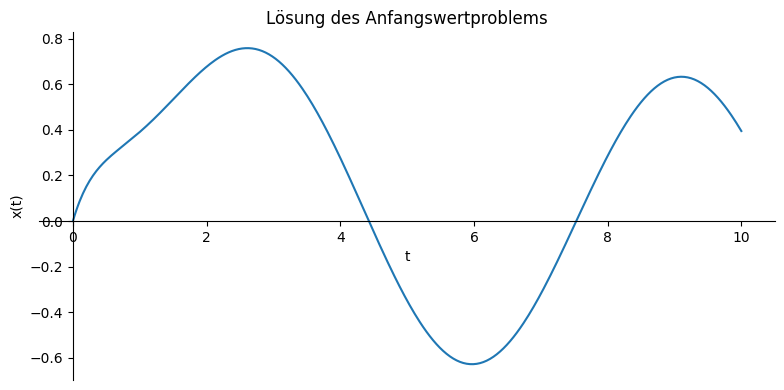

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(t_vals, x_vals)

ax.spines['left'].set_position('zero')    # y-Achse bei t = 0
ax.spines['bottom'].set_position('zero')  # x-Achse bei x(t) = 0

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel('t')
ax.set_ylabel('x(t)')
ax.set_title('Lösung des Anfangswertproblems')

ax.grid(False)
plt.tight_layout()
plt.show()